Install & Import Libraries

In [1]:
!pip install tensorflow matplotlib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

Sample Encoder Outputs

In [2]:
encoder_outputs = tf.random.normal((1, 5, 8))

print("Encoder Outputs Shape:")
print(encoder_outputs.shape)

Encoder Outputs Shape:
(1, 5, 8)


Decoder Hidden State

In [3]:
decoder_hidden = tf.random.normal((1, 8))

print("Decoder Hidden State Shape:")
print(decoder_hidden.shape)

Decoder Hidden State Shape:
(1, 8)


Bahdanau Attention Class

In [4]:
class BahdanauAttention(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()

        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):

        query = tf.expand_dims(query, 1)

        score = self.V(
            tf.nn.tanh(
                self.W1(values) + self.W2(query)
            )
        )

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

Create Attention Layer

In [5]:
attention = BahdanauAttention(16)

context_vector, attention_weights = attention(
    decoder_hidden,
    encoder_outputs
)

print("Context Vector Shape:")
print(context_vector.shape)

print("\nAttention Weights:")
print(attention_weights.numpy())

Context Vector Shape:
(1, 8)

Attention Weights:
[[[0.19391163]
  [0.12576827]
  [0.09761986]
  [0.48924953]
  [0.09345066]]]


Visualize Attention

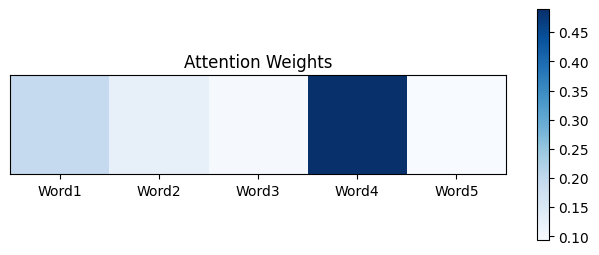

In [6]:
plt.figure(figsize=(8,3))

plt.imshow(attention_weights.numpy().reshape(1,-1), cmap="Blues")

plt.colorbar()

plt.yticks([])

plt.xticks(range(5), ["Word1","Word2","Word3","Word4","Word5"])

plt.title("Attention Weights")

plt.show()

User Example

In [7]:
sentence = ["Natural","Language","Processing","is","awesome"]

weights = attention_weights.numpy().flatten()

print("Word Attention Scores\n")

for word, weight in zip(sentence, weights):
    print(f"{word:<15} {weight:.4f}")

Word Attention Scores

Natural         0.1939
Language        0.1258
Processing      0.0976
is              0.4892
awesome         0.0935
